**STEP 1: Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, r2_score

**STEP 2: Load Dataset**

In [2]:
df = pd.read_csv("/content/student_placement_synthetic.csv")

print(df.head())
print(df.info())

     branch college_tier  cgpa  backlogs  coding_skills  dsa_score  \
0       ECE       Tier-3  6.70         0            7.6        4.4   
1  Chemical       Tier-2  5.70         0            5.4        7.9   
2        EE       Tier-2  7.19         0            5.6        6.8   
3        CE       Tier-2  6.48         0            5.2        3.1   
4       CSE       Tier-2  6.71         1            5.9        4.7   

   aptitude_score  communication_skills  ml_knowledge  system_design  \
0            49.5                   3.7           6.4            0.3   
1            72.0                   8.3           6.3            1.9   
2            79.1                   7.4           4.4            5.2   
3            48.4                   5.0           1.1            6.7   
4            61.2                   4.3           2.7            2.8   

   internships  projects_count  certifications  hackathons  \
0            1               4               4           3   
1            0        

**STEP 3: Data Preprocessing**

**3.1 Encode Categorical Data**

In [3]:
df = df.copy()

# Label Encoding
le_branch = LabelEncoder()
le_tier = LabelEncoder()

df['branch'] = le_branch.fit_transform(df['branch'])
df['college_tier'] = le_tier.fit_transform(df['college_tier'])

**3.2 Handle Missing Values**

In [4]:
# Salary missing → keep for regression later
df_salary = df.dropna(subset=['salary_package_lpa'])

**Visualization Before Training**

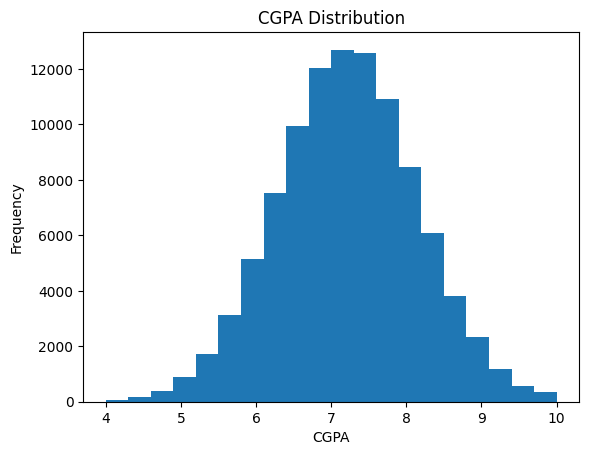

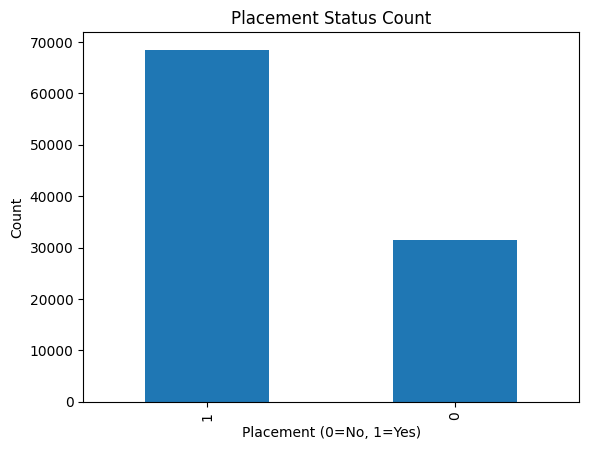

<Figure size 640x480 with 0 Axes>

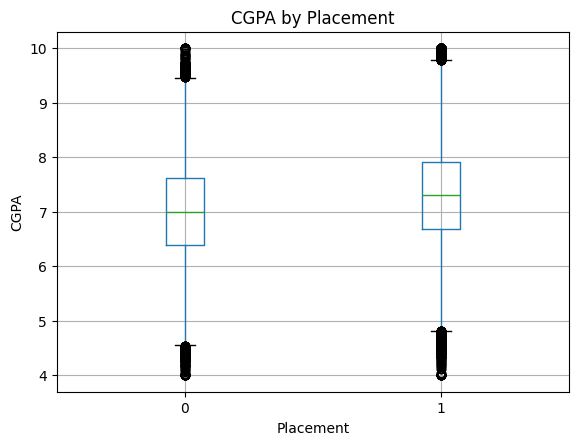

In [23]:
import matplotlib.pyplot as plt

# CGPA distribution
plt.figure()
df['cgpa'].plot(kind='hist', bins=20)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()


# Placement distribution
plt.figure()
df['placement_status'].value_counts().plot(kind='bar')
plt.title("Placement Status Count")
plt.xlabel("Placement (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()
# CGPA distribution by placement
plt.figure()
df.boxplot(column='cgpa', by='placement_status')
plt.title("CGPA by Placement")
plt.suptitle("")
plt.xlabel("Placement")
plt.ylabel("CGPA")
plt.show()

**Feature vs Target (Important)**

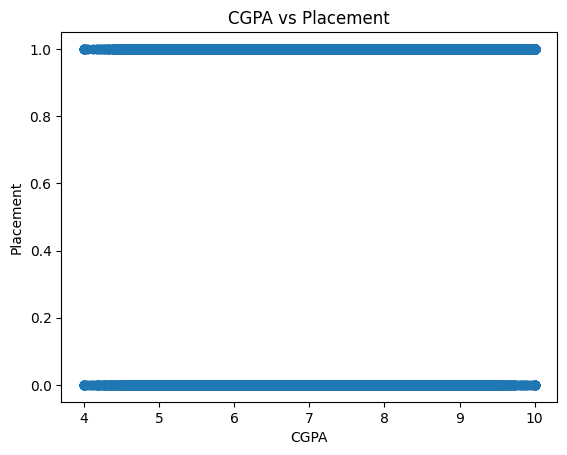

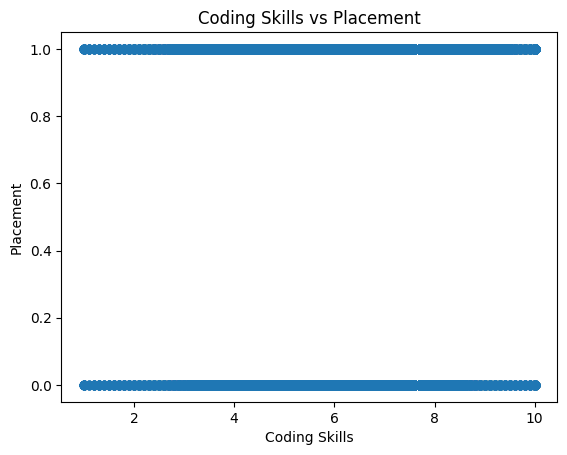

In [22]:
# CGPA vs Placement
plt.figure()
plt.scatter(df['cgpa'], df['placement_status'])
plt.title("CGPA vs Placement")
plt.xlabel("CGPA")
plt.ylabel("Placement")
plt.show()


# Coding skills vs Placement
plt.figure()
plt.scatter(df['coding_skills'], df['placement_status'])
plt.title("Coding Skills vs Placement")
plt.xlabel("Coding Skills")
plt.ylabel("Placement")
plt.show()

**Correlation Matrix**

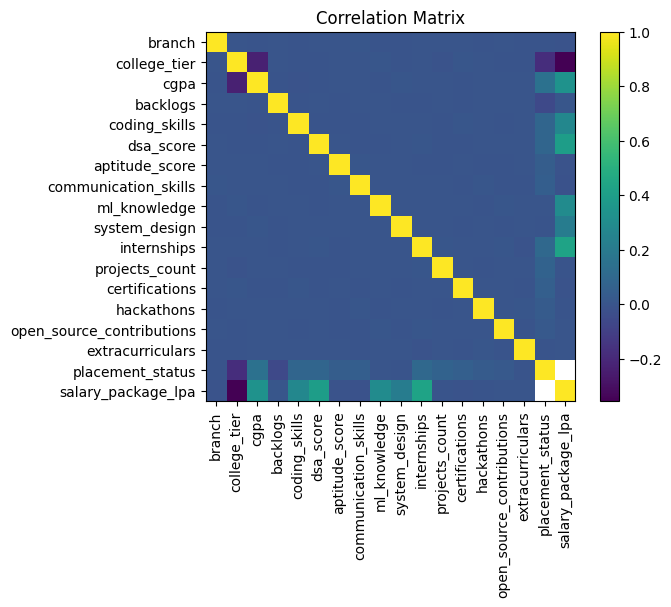

In [24]:
corr = df.select_dtypes(include='number').corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

**Feature Importance**

In [25]:
# simple correlation with target
corr_target = corr['placement_status'].sort_values(ascending=False)

print(corr_target)

placement_status             1.000000
cgpa                         0.148932
internships                  0.099967
coding_skills                0.087657
dsa_score                    0.086594
projects_count               0.069900
certifications               0.055636
communication_skills         0.051034
aptitude_score               0.045146
hackathons                   0.033315
open_source_contributions    0.022723
ml_knowledge                 0.002097
branch                      -0.001470
system_design               -0.001583
extracurriculars            -0.004807
backlogs                    -0.058815
college_tier                -0.180052
salary_package_lpa                NaN
Name: placement_status, dtype: float64


**PART 1: CLASSIFICATION MODEL (Placement Prediction)**

**STEP 4: Define Features & Target**

In [5]:
X = df.drop(['placement_status', 'salary_package_lpa'], axis=1)
y = df['placement_status']

**STEP 5: Train-Test Split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**STEP 6: Feature Scaling**

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**STEP 7: Train Model (Random Forest)**

In [8]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**STEP 8: Evaluation**

In [9]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.69395
              precision    recall  f1-score   support

           0       0.55      0.19      0.29      6335
           1       0.71      0.93      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.63      0.56      0.55     20000
weighted avg       0.66      0.69      0.64     20000



**PART 2: REGRESSION MODEL (Salary Prediction)**

**STEP 9: Prepare Data (Only Placed Students)**

In [10]:
X_reg = df_salary.drop(['salary_package_lpa', 'placement_status'], axis=1)
y_reg = df_salary['salary_package_lpa']

**STEP 10: Train-Test Split**

In [11]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

**STEP 11: Scaling**

In [12]:
scaler_r = StandardScaler()

X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r = scaler_r.transform(X_test_r)

**STEP 12: Train Model (Random Forest Regressor)**

In [13]:
reg = RandomForestRegressor(n_estimators=100, random_state=42)

reg.fit(X_train_r, y_train_r)

RandomForestRegressor(random_state=42)

**STEP 13: Evaluation**

In [14]:
y_pred_r = reg.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2 Score:", r2_score(y_test_r, y_pred_r))

MAE: 1.0136843957648778
R2 Score: 0.760009665413228


**STEP 14: Feature Importance (VERY IMPORTANT)**

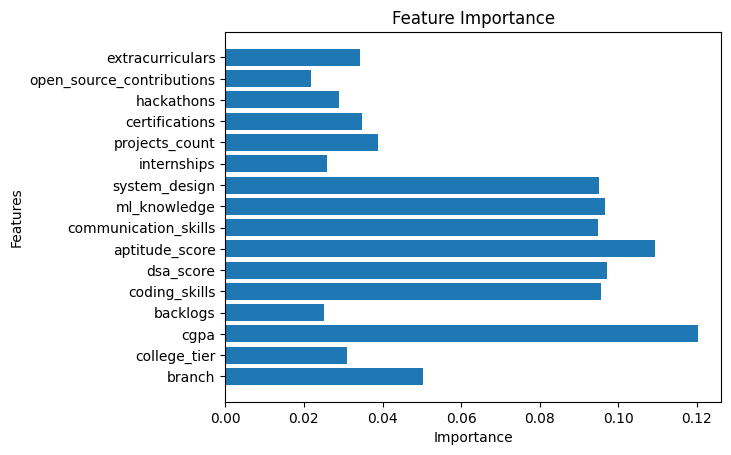

In [15]:
import matplotlib.pyplot as plt

importance = clf.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

**📊 Confusion Matrix Code**

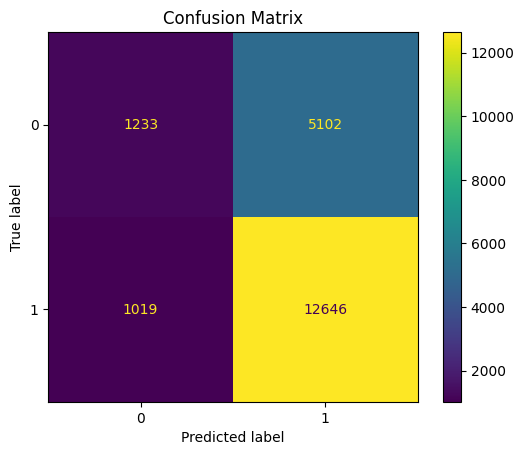

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

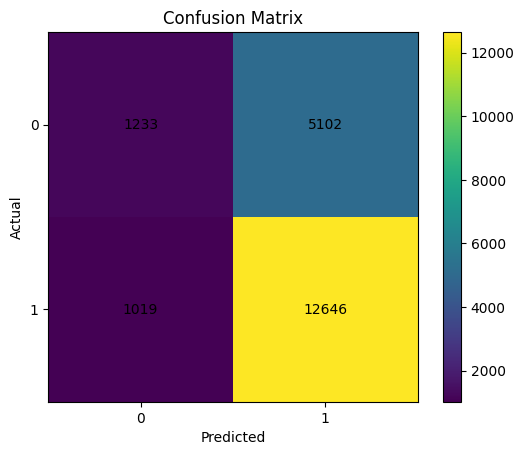

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0,1])
plt.yticks([0,1])

# show values inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

**📊 1. Classification Report**

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.19      0.29      6335
           1       0.71      0.93      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.63      0.56      0.55     20000
weighted avg       0.66      0.69      0.64     20000



**📊 2. Convert Report to Table (Better View)**

In [19]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print(df_report)

              precision    recall  f1-score      support
0              0.547513  0.194633  0.287178   6335.00000
1              0.712531  0.925430  0.805144  13665.00000
accuracy       0.693950  0.693950  0.693950      0.69395
macro avg      0.630022  0.560031  0.546161  20000.00000
weighted avg   0.660262  0.693950  0.641079  20000.00000


**Visualization**

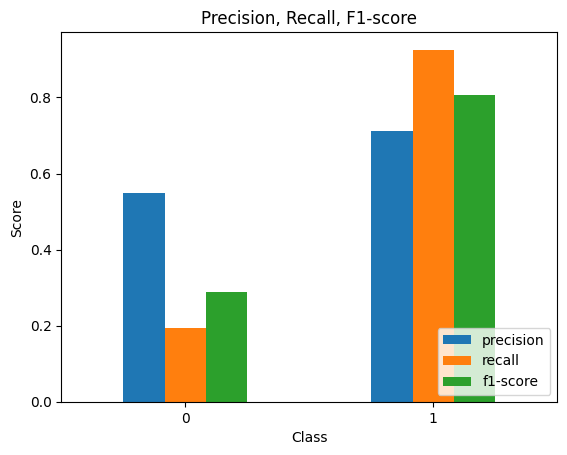

In [20]:
import matplotlib.pyplot as plt

# select only main classes (0 and 1)
df_plot = df_report.iloc[:2, :3]  # precision, recall, f1-score

df_plot.plot(kind='bar')

plt.title("Precision, Recall, F1-score")
plt.xlabel("Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.show()